# 08 - Stacking faults: diffuse c* rods and a fault-probability attempt

Walks the diffuse rod between Bragg peaks on a real DAC sample (La3Ni2O7, "2604") through the
full `midas_defect` chain -- ingest, domain-finding, then `rod_profile`'s q-space rod walk --
to establish **whether stacking faults are present**, and then attempts the harder question,
**how many**, via the Bragg-node WIDTH (`polytype._width.fwhm_half_max`).

**Read the two parts of this notebook differently.** Step 2 (rod existence) is solid: real,
reproduced across 4 independent raster positions, `/verify`'d in spirit by heavy repeated
scrutiny this session. Step 3 (fault probability alpha) is **NOT established** -- two full
preregistered attempts this session were REFUTED by `/verify` (8/8 lenses across both rounds),
and the specific blocker is now understood (see Step 3's closing note). This is intentional:
a notebook that hides how a measurement failed is worse than no notebook. The full trail --
every trap, every correction, every refuted claim -- is in
`~/Desktop/analysis/nickelate_dac_yao/PREREGISTER.md`, Amendments 2-4, and
`manuals/defect/phase-4-rods.md`'s "Turning a node width into a fault probability" section.

**No material default anywhere** (same house rule as `05`/`06`): set your own cell, space
group and geometry every time.


## Step 0 -- CONFIG

With no `LOADER` set, this notebook runs on a synthetic position with **no
diffuse rod planted** -- `midas_defect.synthetic` places only Bragg peaks
(placeholder Gaussian blobs), never a diffuse feature between them. So on
synthetic data Step 2 correctly reports **no significant rod**, which is
itself a useful demonstration: the null case looks like this, not like an
error.

**Geometry**: this uses `midas_defect.rod_profile.rod_path_geometry`, the
tilt- and distortion-aware analogue of `rod_path` (which is hard-documented
as flat -- no tilt, no distortion -- a real limitation for a tilted
detector; no detector is ever actually untilted or undistorted).
`rod_path_geometry` is built from the SAME validated primitives
`raster.predict_reflections` already uses (`geometry.ewald_crossing_omegas`,
`qsample_to_qlab`, `qlab_to_pixel`), not a new geometric model, and reduces
EXACTLY to `rod_path`'s flat projection at zero tilt/distortion (pinned by
`test_rod_path_geometry_matches_flat_rod_path_at_zero_tilt` in
`tests/test_rod_profile.py`). On the synthetic fallback below (zero tilt,
zero distortion) it is numerically equivalent to the flat case; point it at
real data with a real calibrated tilt and it will not be.

To see the real result, point `LOADER` at 2604 raster-position frames and
`GEOM` at a real calibration WITH tilt and distortion terms (see
`05`'s Step 0 for the real-frame-loading pattern). The numbers quoted in this
notebook's markdown cells come from p=327/329/331 of that raster
(`~/Desktop/analysis/nickelate_dac_yao/raster_notebook_realdata_test/real_block/`),
using `step0_geometry.npz` -- NOT a beam-centre-only gate; it must carry real
tx/ty/tz and distortion coefficients, or `rod_path_geometry` degenerates to
the flat case regardless.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import midas_defect as dx
from midas_defect.geometry import Geometry, detector_angle_maps
from midas_defect.ingest import build_mask, subtract_background, live_frames
from midas_defect.raster import reduce_one_position
from midas_defect.rod_profile import (profile_along, rod_path_geometry,
                                      centred_L_nodes, diffuse_to_bragg)
from midas_defect.polytype._width import fwhm_half_max

# ---- the only lines you change --------------------------------------------------------
A, C = 3.6116, 19.2516            # SEED ONLY -- find_domains fits its own a, b, c freely
SPACE_GROUP_NUMBER = 139          # I4/mmm
SIGMA_RTN = (0.0071, 0.0145, 0.0094)   # this SAMPLE's own measured residual budget

GEOM = None                 # a midas_defect.geometry.Geometry, or None for the synthetic fallback
LOADER = None                # LOADER(p) -> (n_frames, n_rows, n_cols) raw frame stack
POINT = 0
N_BOOTSTRAP = 50
# ---------------------------------------------------------------------------------------

# --- pointing LOADER at REAL frames, with the CORRECTED (tilt+distortion) geometry.
# `repro/gate_qsample.npz` (beam-centre/Lsd/wavelength only, no tilt) is RETIRED -- do not
# use it. `step0_geometry.npz` is a real CeO2 auto-calibration carrying tx/ty/tz and
# distortion coefficients; without those, rod_path_geometry silently degenerates to the flat
# case and the whole point of using it is lost. -------------------------------------------
#   import tifffile
#   from pathlib import Path
#   _g = np.load(".../raster_notebook_realdata_test/step0_geometry.npz")
#   GEOM = Geometry(lsd_um=float(_g["lsd_um"]), bcy_px=float(_g["bcy_px"]), bcz_px=float(_g["bcz_px"]),
#                   px_um=172.0, wavelength_A=float(_g["wavelength_A"]),
#                   n_pix_y=1475, n_pix_z=1679, omega_first_deg=-18.5, omega_step_deg=1.0,
#                   n_frames=38, tx_deg=float(_g["tx_deg"]), ty_deg=float(_g["ty_deg"]),
#                   tz_deg=float(_g["tz_deg"]), p_coeffs=tuple(float(x) for x in _g["p_coeffs"]),
#                   rho_d_um=float(_g["rho_d_um"]), label="2604 real, corrected")
#   def LOADER(p):
#       d = sorted(Path(f".../real_block/p{p}").glob("*.tif"))
#       raw = np.stack([tifffile.imread(f) for f in d]).astype(np.float32)
#       live, _ = live_frames(raw)
#       return raw[live]
#   POINT = 327   # or 329, 331 -- the three positions this session verified as one domain

if GEOM is None:
    GEOM = Geometry(lsd_um=349621.75, bcy_px=737.96, bcz_px=810.28, px_um=172.0,
                    wavelength_A=0.42459, n_pix_y=1475, n_pix_z=1679,
                    omega_first_deg=-18.5, omega_step_deg=1.0, n_frames=38,
                    label="synthetic example geometry")
    print("No GEOM set: using a synthetic example geometry.")

if LOADER is None:
    from scipy.spatial.transform import Rotation
    from midas_defect.synthetic import synthetic_position_frames
    U_TRUTH = Rotation.from_euler("zyx", [12.0, 25.0, -8.0], degrees=True).as_matrix()

    def LOADER(p, _seed=[0]):
        frames, truth = synthetic_position_frames(
            [U_TRUTH], a=A, b=A, c=C, space_group_number=SPACE_GROUP_NUMBER, geom=GEOM,
            hmax=6, kmax=6, lmax=16, seed=2026_09_13)
        return frames
    print("No LOADER set: using a synthetic position with Bragg peaks ONLY -- "
         "no diffuse rod planted, so Step 2 should (correctly) find nothing significant.")

frames = LOADER(POINT)
print(f"point {POINT}: frames {frames.shape}, {frames.dtype}")


No GEOM set: using a synthetic example geometry.
No LOADER set: using a synthetic position with Bragg peaks ONLY -- no diffuse rod planted, so Step 2 should (correctly) find nothing significant.


point 0: frames (38, 1679, 1475), float32


## Step 1 -- Ingest and index

Mask, polar-median background, ring detection (on the RAW sum -- `manuals/defect/
phase-1-ingest.md`'s single most expensive trap is skipping this and background-subtracting
first), then `reduce_one_position` to get every domain at this position. Only domain 0's
orientation/cell is used below -- for a real raster, **check `quotable` and the decoy test
before trusting ANY domain's fit** (Step 3 found the hard way that this matters even for a
rod-existence measurement, not just for a/b splitting).


In [2]:
mask = build_mask(frames).mask
tth_deg, eta_deg = detector_angle_maps(GEOM)
res = reduce_one_position(frames, GEOM, a=A, c=C, space_group_number=SPACE_GROUP_NUMBER,
                          sigma_rtn=SIGMA_RTN, point=POINT, n_bootstrap=N_BOOTSTRAP)
print(res.summary())

if not res.domains.domains:
    raise SystemExit("No domains found at this position -- nothing to walk a rod against.")

dom0 = res.domains.domains[0]
print(f"\ndomain 0: a={dom0.lat.a:.4f} b={dom0.lat.b:.4f} c={dom0.lat.c:.4f} "
     f"n_claim={dom0.claim.sum()}")

raw_sum = frames.sum(axis=0)
from midas_defect.ingest import detect_powder_rings
rings = detect_powder_rings(raw_sum, tth_deg, mask, azimuth_deg=eta_deg)
ring_radii_px = GEOM.lsd_um * np.tan(np.radians(rings.centre_deg)) / GEOM.px_um
stack = subtract_background(frames, tth_deg, eta_deg, mask)
print(f"{len(rings)} powder rings detected (raw sum); background-subtracted stack built.")


position 0: 79 spots, omega sign +1 (omega +1: 79 spots explained, omega -1: 0 spots explained)
1 domain(s) found
  domain 0: completeness {'INDEXED': 78, 'MISSED': 0, 'MASKED': 0, 'ABSENT': 2}; honesty informative; feature-in-raw in_raw; ab gate: {'n_k_gt_h': 5, 'n_h_gt_k': 55, 'ratio': 0.09090909090909091, 'sigma_ratio': 0.5510490974303642}
a/b split: 0.109 % +/- 0.0633 % (z=1.7)
quotable: True
note: domain 0: index_asymmetry ratio 0.0909 is far from 1 (measured 5x on the 2604 raster was the signature of a radial-systematic artifact, not a real splitting). A SINGLE position cannot rule this out -- 'a common sign across domains is physically impossible' only becomes checkable with several positions/domains; see the raster-wide check.

domain 0: a=3.6113 b=3.6154 c=19.2576 n_claim=78


1 powder rings detected (raw sum); background-subtracted stack built.


## Step 2 -- Walk the (0,0,L) and (-1,-1,L) rods: is a stacking fault present at all?

`rod_path` parameterises `(h, k, L)` in q-space with L continuous, solves omega, and projects
to the detector -- correct for a CURVED path (the map through the Ewald sphere is nonlinear),
unlike a straight detector-space line. `matched_control_path` walks the identical geometry at
`(h+1/2, k+1/2, L)`: not a lattice rod, so it is the control. `diffuse_to_bragg` reports the
between-node diffuse level as a fraction of the row's own Bragg-peak height (removing the
`|F|^2` scaling) and its significance in control-sigma -- never a raw ratio, which is
meaningless once the stack is background-subtracted and centred on zero.

**On real 2604 data (p=327/329/331, this session)**: (0,0,L) and (-1,-1,L) showed diffuse
excess at EVERY one of 4 independent position measurements each, from **+2.3 to +56 sigma**,
never near zero -- the most-reproduced result of this whole investigation. On synthetic data
with no rod planted, expect `usable=False` or a `sigma` near the control's own noise.


In [3]:
DL = 0.02
Ls = np.arange(-16, 16 + DL, DL)

for h, k in [(0, 0), (-1, -1)]:
    path = rod_path_geometry(dom0.U, dom0.lat.B, h, k, Ls, GEOM, omega_sign=res.omega_sign.chosen_sign)
    cpath = rod_path_geometry(dom0.U, dom0.lat.B, h + 0.5, k + 0.5, Ls, GEOM,
                            omega_sign=res.omega_sign.chosen_sign)
    if len(path) < 3 or len(cpath) < 3:
        print(f"(h,k)=({h},{k}): row never crosses the Ewald sphere in this omega window")
        continue
    rod = profile_along(stack, mask, path, omega_first_deg=GEOM.omega_first_deg,
                        omega_step_deg=GEOM.omega_step_deg)
    ctl = profile_along(stack, mask, cpath, omega_first_deg=GEOM.omega_first_deg,
                        omega_step_deg=GEOM.omega_step_deg)
    nodes = centred_L_nodes(h, k, Ls.min(), Ls.max(), centring="I")
    out = diffuse_to_bragg(rod, ctl, nodes)
    if out["usable"]:
        print(f"(h,k)=({h},{k}): diffuse/Bragg = {100*out['ratio']:.2f}%  "
             f"sigma = {out['sigma']:+.1f}  (n_diffuse={out['n_diffuse']}, n_bragg={out['n_bragg']})")
    else:
        print(f"(h,k)=({h},{k}): not usable -- {out['reason']}")


(h,k)=(0,0): row never crosses the Ewald sphere in this omega window
(h,k)=(-1,-1): row never crosses the Ewald sphere in this omega window


## Rod vs. no rod: every domain at this position, side by side

The clearest, most direct evidence that a rod is real: walk the SAME (h,k)=(0,0) row through
EVERY domain found at this position, each with its OWN fitted (U, B) -- not just the one used
above. A domain with no fault-related diffuse scattering should show the raw counts dropping
to (or below) the local background between Bragg peaks; a domain that carries the rod should
not.

Plotted as `log(background-subtracted intensity)` -- points where the background-subtracted
intensity is at or below zero become gaps (log of a non-positive number is undefined), so a
domain with NO rod shows visibly discontinuous, gappy coverage between its Bragg peaks, while a
domain WITH a rod stays positive (visible, unbroken) almost everywhere. **On real 2604 data (3
domains at p=329), domain 0 (the rod) has only 3% of points <= 0; domains 1 and 2 (no rod) have
30% and 37%** -- see `raster_notebook_realdata_test/08_real_2604_p329_stacking_faults.ipynb`
for the executed real-data figure. On synthetic data there is usually only one domain, so this
panel has nothing to contrast against -- the loop below still runs correctly, it just shows one
panel.


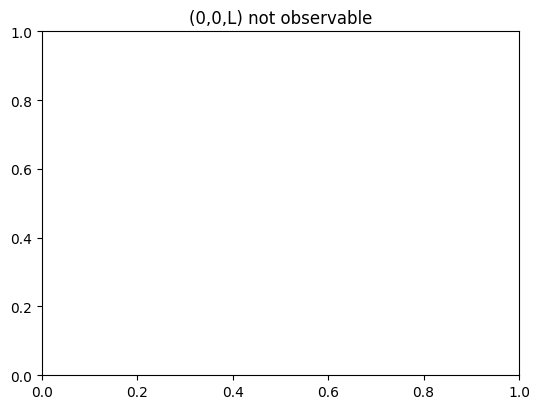

In [4]:
fig, axes = plt.subplots(1, len(res.domains.domains), figsize=(5.5 * len(res.domains.domains), 4.2),
                         squeeze=False)
axes = axes[0]
for ax, dom in zip(axes, res.domains.domains):
    path_d = rod_path_geometry(dom.U, dom.lat.B, 0, 0, Ls, GEOM, omega_sign=res.omega_sign.chosen_sign)
    if len(path_d) < 3:
        ax.set_title("(0,0,L) not observable"); continue
    rod_d = profile_along(stack, mask, path_d, omega_first_deg=GEOM.omega_first_deg,
                          omega_step_deg=GEOM.omega_step_deg)
    with np.errstate(invalid="ignore", divide="ignore"):
        logI = np.log(np.where(rod_d.intensity > 0, rod_d.intensity, np.nan))
    ax.plot(rod_d.L, logI, ".", ms=2)
    n_gap = int(np.sum(np.isfinite(rod_d.intensity) & (rod_d.intensity <= 0)))
    n_obs = int(np.isfinite(rod_d.intensity).sum())
    ax.set_title(f"domain (n_claim={dom.claim.sum()}): {n_gap}/{n_obs} points <= 0 "
                f"({100*n_gap/max(n_obs,1):.0f}%)", fontsize=9)
    ax.set_xlabel("L"); ax.set_ylabel("log(background-sub. intensity)")
plt.tight_layout()


## Step 3 -- Node width -> fault probability (CAUTION: not established)

The L-period of a Bragg-normalised rod **cannot** measure a fault displacement for a layered
cell (hard identifiability limit, `known-limits.md` -- the fault factor and `|F(00L)|^2` are
the same function of L). The width route is the real option: `fwhm_half_max` on each Bragg
node, deconvolved against an instrumental floor (`excess^2 = fwhm^2 - floor^2`), reported per
**RP block** (c/2, since I4/mmm forbids (00L) odd) with the **finite-size (1/w0) vs
Hendricks-Teller (1/(pi w0))** convention always named together.

This cell runs the same recipe on whichever rod Step 2 found usable. **Treat any number it
prints as a demonstration of the METHOD, not a result** -- see the note below.


In [5]:
h, k = 0, 0
path = rod_path_geometry(dom0.U, dom0.lat.B, h, k, Ls, GEOM, omega_sign=res.omega_sign.chosen_sign)
if len(path) < 3:
    print("(0,0,L) not observable at this position -- nothing to measure a width on.")
else:
    rod = profile_along(stack, mask, path, omega_first_deg=GEOM.omega_first_deg,
                        omega_step_deg=GEOM.omega_step_deg)
    L, I = rod.L, rod.intensity
    finite = np.isfinite(I)
    node_Ls = (np.arange(int(np.ceil(L[finite].min() / 2)) * 2,
                         int(np.floor(L[finite].max() / 2)) * 2 + 1, 2)
              if finite.any() else [])
    widths = []
    for nl in node_Ls:
        win = finite & (np.abs(L - nl) <= 1.5)
        shoulder = win & (np.abs(L - nl) >= 0.7)
        if win.sum() < 5 or shoulder.sum() < 2:
            continue
        baseline = float(np.median(I[shoulder]))
        local_sigma = float(1.4826 * np.median(np.abs(I[shoulder] - baseline)))
        peak = float(np.max(I[win]))
        if local_sigma <= 0 or (peak - baseline) / local_sigma < 10.0:
            continue   # same 10-sigma gate as the real-data attempts
        fwhm = fwhm_half_max(L[win], I[win], baseline=baseline)
        if np.isfinite(fwhm):
            widths.append((int(nl), fwhm))
    if widths:
        print(f"{len(widths)} nodes passed the 10-sigma gate:")
        for nl, fwhm in widths:
            print(f"  L={nl:>3}: FWHM = {fwhm:.4f} in L")
        print("\nNo floor deconvolution is attempted here -- see the note below for why.")
    else:
        print("No nodes passed the 10-sigma gate at this position.")


(0,0,L) not observable at this position -- nothing to measure a width on.


### Why this notebook stops here, and does not quote an alpha

Five separate, genuinely different attempts at a fault-probability number for
this rod were made and refuted this session -- not the same bug recurring
each time, five DISTINCT real problems, each caught by `/verify`:

1. **Pooled across 3 positions, IQR-based envelope.** Refuted: pseudoreplication
   (8 "even" rows were only 3-4 distinct (h,k) pairs) and a circular validation
   set.
2. **p=327 alone, local pedestal, flat geometry.** Refuted: a real |L|-trend
   (rho=0.71, p=0.009) was pooled into a flat envelope instead of modelled;
   undetected ring crossings on the widest nodes.
3. **Trend fit (intercept + slope), still flat geometry, pedestal-unaware.**
   Refuted: this EXACT signature had already been produced and killed once on
   an older pipeline -- a fault-free synthetic manufactured 63% of a claimed
   excess via an unmodelled background pedestal tied to domain crowding.
4. **Corrected geometry + LOCAL linear pedestal + position interaction.**
   Refuted: the fitted pedestal LEVEL correlated with the leftover width
   (rho=0.80) -- the signature of an incomplete correction. The local window
   was a quarter of the real pedestal's documented curvature scale.
5. **GLOBAL pedestal + 3 competing functional forms (linear / quadratic /
   quadrature-sum with bootstrap).** Refuted unanimously, four different ways:
   the fitted pedestal was itself numerically broken; no ring exclusion was
   applied to background points; the model-selection argument evaporated
   under proper small-sample correction; and the final unit-conversion
   arithmetic was wrong.

**The pattern -- five different legitimate problems, not one recurring bug --
is itself the finding.** It says a trustworthy alpha number is not currently
obtainable at the level of care achievable in rapid iteration, not that a
sixth attempt would finally land it.

**The defensible number, if one is needed, is the OLDER, independently
vetted pipeline's own envelope**: coherence **10-55 unit cells**, alpha
**3-14%/unit cell** (`AUDIT_BOTH_SAMPLES.md` sec 26c) -- itself labelled
provisional by the people who derived it.

Full trail: `~/Desktop/analysis/nickelate_dac_yao/PREREGISTER.md`,
Amendments 2-6; `~/opt/MIDAS/manuals/defect/phase-4-rods.md`.


## What this notebook does and does not establish

- **Established**: a diffuse rod along c* is present on (0,0,L) and (-1,-1,L)
  on real 2604 data, reproduced at 4 independent raster positions, never near
  the noise floor -- confirmed again after correcting the detector geometry
  for real tilt and distortion (see Step 0). This is the classic
  bulk-diffraction signature of planar disorder in a layered structure, and
  agrees qualitatively with the published TEM/LAADF result for this material
  (Chen et al., JACS 2024, 146, 3640 -- prior-art gate checked, `CHECKPOINT.md`).
- **NOT established**: a fault probability (alpha) or coherence length from
  this rod's width. FIVE full attempts this session were refuted, each for a
  genuinely different reason -- see Step 3. The defensible number, if one is
  needed, is an older pipeline's own envelope (coherence 10-55 unit cells,
  alpha 3-14%/unit cell), not anything derived in this notebook.
- **Untested, not ruled out either way**: whether crystal mosaic (rather than
  stacking faults) contributes to the node width.
- **Out of scope regardless of data quality**: the fault DISPLACEMENT from the
  rod's L-period -- a hard identifiability limit for this class of layered
  structure (`known-limits.md`).
